# Q1 2025 visibility exception root-cause analysis

This notebook evaluates whether canonical port-call events are complete enough for a downstream shipment-visibility workflow. It turns source exceptions into a documented action: retain, exclude from completed-event coverage, or resolve through canonicalisation.

Source: Fintraffic Digitraffic Port Call API, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). The published Q1 CSV snapshot includes the selected source fields and derived outputs used below.


## Question and scope

For Q1 2025, what event-quality exceptions prevent a port-call event from entering completed-event coverage, how many records do they affect, and what is the appropriate downstream handling?

The quality grain is one canonical actual port-area event. This is not a measure of shipment delay, port performance, ETA accuracy, or reporting latency.

In [1]:
from base64 import b64encode
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display
import pandas as pd

pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def find_data_dir():
    for folder in (Path.cwd(), *Path.cwd().parents):
        candidate = folder / 'data' / 'q1-2025'
        if (candidate / 'canonical_port_area_events.csv').exists():
            return candidate
    raise FileNotFoundError('Q1 CSV snapshot not found. Run from the project directory after cloning the repository.')

data_dir = find_data_dir()
events = pd.read_csv(data_dir / 'canonical_port_area_events.csv')
exceptions = pd.read_csv(data_dir / 'exception_register.csv')
quality_summary = pd.read_csv(data_dir / 'quality_summary.csv')

print(f'Loaded {len(events):,} canonical events and {len(exceptions):,} exception-register rows.')


Loaded 7,172 canonical events and 95 exception-register rows.


## 1. Reconciliation boundary

The source build preserves the raw event count, creates canonical actual events, and records the source rows that were collapsed because they describe the same actual milestone.

In [3]:
quality_summary[['metric', 'count', 'denominator', 'rate', 'note']]

,metric,count,denominator,rate,note
0,source_response_records,7135,NaN,NaN,Reconciled to the published request manifest.
1,raw_port_area_rows,7176,NaN,NaN,Nested quality grain before canonicalisation.
2,canonical_port_area_events,7172,NaN,NaN,Distinct canonical event keys.
3,collapsed_duplicate_source_rows,4,7176.0,0.0006,Extra source rows represented by an identical ...
4,eligible_completed_events,7081,7172.0,0.9873,"Has ATA, ATD, and a non-negative actual interval."
5,events_missing_ata,32,7172.0,0.0045,Blocked from completed-event coverage.
6,events_missing_atd,59,7172.0,0.0082,Blocked from completed-event coverage.
7,negative_actual_intervals,0,7172.0,0.0000,Blocked from completed-event coverage.
8,exception_register_rows,95,NaN,NaN,One event may have more than one issue.
9,duplicate_source_events,4,7172.0,0.0006,Resolved by retaining one event with full line...


## 2. Exception register

A blocking exception keeps the event in the register but removes it from completed-event coverage. A resolved canonicalisation issue keeps one actual event and full source lineage.

In [4]:
exception_summary = (
    exceptions.groupby(['severity', 'issue_type', 'state', 'remediation_rule'], as_index=False)
    .agg(canonical_events=('canonical_event_id', 'nunique'), source_rows=('affected_source_rows', 'sum'))
    .sort_values(['severity', 'canonical_events'], ascending=[True, False])
)
exception_summary['share_of_canonical_events'] = exception_summary['canonical_events'] / len(events)
exception_summary

,severity,issue_type,state,remediation_rule,canonical_events,source_rows,share_of_canonical_events
2,blocking,missing_atd,open_source_gap,Exclude from completed-event coverage and reta...,59,60,0.008226
1,blocking,missing_ata_and_atd,open_source_gap,Exclude from completed-event coverage and reta...,18,19,0.002510
0,blocking,missing_ata,open_source_gap,Exclude from completed-event coverage and reta...,14,14,0.001952
3,review_required,duplicate_actual_event,resolved_by_canonicalisation,Collapse identical actual-event fingerprints a...,4,8,0.000558



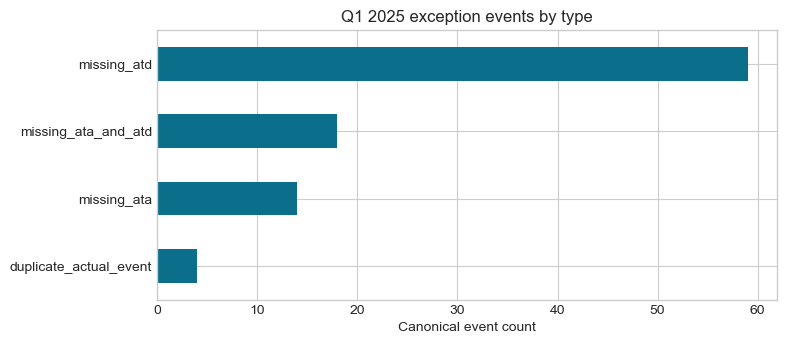

In [5]:
issue_counts = exception_summary.set_index('issue_type')['canonical_events'].sort_values()
ax = issue_counts.plot.barh(figsize=(8, 3.5), color='#0b6e8a')
ax.set_title('Q1 2025 exception events by type')
ax.set_xlabel('Canonical event count')
ax.set_ylabel('')
figure = ax.get_figure()
buffer = BytesIO()
figure.savefig(buffer, format='png', bbox_inches='tight')
plt.close(figure)
image_data = b64encode(buffer.getvalue()).decode()
display(HTML(f'<img alt="Horizontal bar chart of Q1 2025 exception events by issue type." src="data:image/png;base64,{image_data}">'))

## 3. Root-cause evidence and handling

Four source rows describe an already represented actual event. Three come from `portCallId` `3223844` appearing in two daily request chunks; one comes from duplicated actual timestamps in `portCallId` `3217766`, where ETA/ETD forecasts differ but the actual milestone does not. The canonical rule retains one event and every source position.

The remaining blocking events lack at least one actual timestamp. The source does not justify imputing it from an estimate or from the current time, so these events remain open source gaps. This dataset traces the issue to the source event but cannot establish the upstream operational cause of a missing milestone.

In [6]:
resolved_duplicates = events.query("canonicalisation_decision == 'collapsed_same_actual_event'")
resolved_duplicates[['port_call_id', 'port_code', 'source_row_count', 'source_response_count', 'source_chunks', 'completed_event_status']]

,port_call_id,port_code,source_row_count,source_response_count,source_chunks,completed_event_status
2696,3223844,FIKOK,2,2,port_calls__20250205T000000Z__20250206T000000Z...,blocked_missing_atd
2697,3223844,FIKOK,2,2,port_calls__20250205T000000Z__20250206T000000Z...,eligible
2698,3223844,FIKOK,2,2,port_calls__20250205T000000Z__20250206T000000Z...,blocked_missing_ata_and_atd
3683,3217766,FIHEL,2,1,port_calls__20250217T000000Z__20250218T000000Z...,eligible


## 4. Completed-event coverage

Coverage is reported only as the share of canonical events with ATA, ATD, and a valid sequence. It is not a service-level or operational-performance metric.

In [7]:
coverage_by_port = (
    events.assign(eligible=events['completed_event_status'].eq('eligible'))
    .groupby('port_code', as_index=False)
    .agg(canonical_events=('canonical_event_id', 'size'), eligible_completed_events=('eligible', 'sum'))
    .assign(completed_event_coverage=lambda frame: frame['eligible_completed_events'] / frame['canonical_events'])
    .sort_values('canonical_events', ascending=False)
)
coverage_by_port.head(10)

,port_code,canonical_events,eligible_completed_events,completed_event_coverage
6,FIHEL,1752,1745,0.996005
25,FIMHQ,698,697,0.998567
22,FILAN,616,616,1.000000
20,FIKTK,560,553,0.987500
7,FIHKO,336,331,0.985119
39,FITKU,323,316,0.978328
26,FINLI,316,313,0.990506
35,FISKV,264,262,0.992424
2,FIECK,261,261,1.000000
34,FIRAU,239,236,0.987448



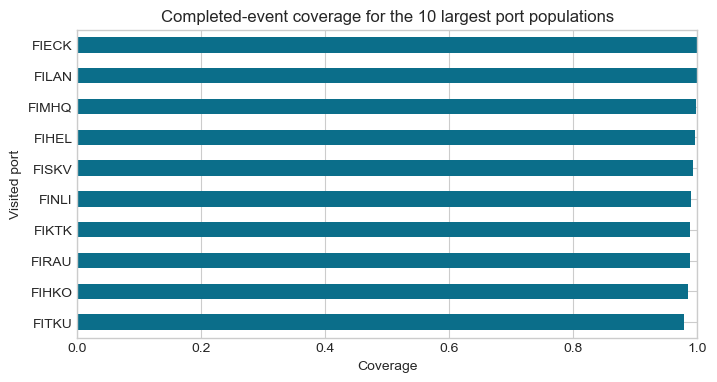

In [8]:
top_ports = coverage_by_port.head(10).sort_values('completed_event_coverage')
ax = top_ports.plot.barh(x='port_code', y='completed_event_coverage', legend=False, figsize=(8, 4), color='#0b6e8a')
ax.set_title('Completed-event coverage for the 10 largest port populations')
ax.set_xlabel('Coverage')
ax.set_ylabel('Visited port')
ax.set_xlim(0, 1)
figure = ax.get_figure()
buffer = BytesIO()
figure.savefig(buffer, format='png', bbox_inches='tight')
plt.close(figure)
image_data = b64encode(buffer.getvalue()).decode()
display(HTML(f'<img alt="Horizontal bar chart of completed-event coverage for the 10 largest port populations." src="data:image/png;base64,{image_data}">'))

## Findings and limits

- The raw-to-canonical reconciliation is complete: 7,176 raw area rows map to 7,172 canonical actual events.
- Four duplicate actual-event rows were resolved without deleting source lineage.
- Events missing actual timestamps are the main blocker for completed-event coverage and remain open source gaps.
- This single public feed does not establish cross-source agreement, forecast accuracy, report latency semantics, or customer impact.